# Audit Congress Trading Signal — Couverture des PTR House (Jours 1–2)

**But.** Construire la *matrice de couverture* côté Chambre des représentants : combien de
**PTR** (`FilingType = "P"`) sont déposés **par année**, quels **autres codes** de dépôt
existent, et la **liste des PTR** à télécharger ensuite — le tout **sans télécharger un seul PDF**,
uniquement à partir des index XML annuels publiés par le Clerk.

**Source** (domaine public, pas de *terms gate*) :
`https://disclosures-clerk.house.gov/public_disc/financial-pdfs/<ANNÉE>FD.zip`
→ chaque ZIP contient `<ANNÉE>FD.xml`. Schéma d'un enregistrement :

```xml
<Member>
  <Prefix>Hon.</Prefix><Last>Aderholt</Last><First>Robert</First><Suffix/>
  <FilingType>P</FilingType><StateDst>AL04</StateDst><Year>2025</Year>
  <FilingDate>9/10/2025</FilingDate><DocID>20032062</DocID>
</Member>
```

**Mode d'emploi.** Exécute les cellules dans l'ordre (*Run All*). Il faut un accès réseau à
`house.gov`. Si une année échoue, elle est journalisée et ignorée (le reste continue).
Pour re-agréger sans réseau à partir de ZIP déjà téléchargés, mets `OFFLINE = True`.

**Ce que ça produit** (dans `./out_house_audit/`) : `coverage_by_year.csv`,
`filing_type_legend.csv`, `manifest.csv`, et un `ptr_index_<ANNÉE>.csv` par année.


## 0. Configuration

In [2]:
import io, time, zipfile, logging
from pathlib import Path
import urllib.request, urllib.error
from xml.etree import ElementTree as ET
import pandas as pd
from IPython.display import display

# --- Paramètres ---
START_YEAR = 2013
END_YEAR   = 2026          # année courante
OUT_DIR    = Path("./out_house_audit")
REQUEST_DELAY = 1.0        # secondes entre téléchargements (politesse serveur public)
OFFLINE = False            # True = ne rien télécharger, ré-agréger les ZIP en cache

BASE_URL   = "https://disclosures-clerk.house.gov/public_disc/financial-pdfs/{year}FD.zip"
PTR_CODE   = "P"           # FilingType d'un Periodic Transaction Report
USER_AGENT = "congress-trading-audit/1.0 (research; coverage audit)"

ZIPS_DIR = OUT_DIR / "raw_zips"
ZIPS_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("house_audit")
print("Années:", START_YEAR, "->", END_YEAR, "| sortie:", OUT_DIR.resolve(),
      "| OFFLINE:", OFFLINE)

Années: 2013 -> 2026 | sortie: /Users/lemairealice/Downloads/Jupiter/Jour 1&2/out_house_audit | OFFLINE: False


## 1. Téléchargement des index (idempotent, rate-limité, tolérant aux erreurs)

Les ZIP sont mis en cache : une ré-exécution ne retélécharge pas. Une année qui échoue
n'interrompt pas les autres. Écriture atomique (`.part` → rename) pour garantir l'idempotence.

def fetch_year_zip(year: int):
    dest = ZIPS_DIR / f"{year}FD.zip"
    if dest.exists() and dest.stat().st_size > 0:
        log.info("année %s : ZIP en cache (%d octets)", year, dest.stat().st_size)
        return dest
    if OFFLINE:
        log.warning("année %s : absente du cache et OFFLINE=True -> ignorée", year)
        return None
    url = BASE_URL.format(year=year)
    log.info("année %s : téléchargement %s", year, url)
    req = urllib.request.Request(url, headers={"User-Agent": USER_AGENT})
    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = resp.read()
    except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as exc:
        log.error("année %s : échec téléchargement (%s)", year, exc)
        return None
    finally:
        time.sleep(REQUEST_DELAY)
    if not data:
        log.error("année %s : réponse vide", year)
        return None
    tmp = dest.with_suffix(".zip.part")
    tmp.write_bytes(data)
    tmp.replace(dest)
    log.info("année %s : écrit %s (%d octets)", year, dest.name, len(data))
    return dest

def read_xml_from_zip(zip_path: Path) -> bytes:
    with zipfile.ZipFile(zip_path) as zf:
        xmls = [n for n in zf.namelist() if n.lower().endswith(".xml")]
        if not xmls:
            raise ValueError(f"{zip_path.name}: aucun .xml dans l'archive")
        xmls.sort(key=lambda n: zf.getinfo(n).file_size, reverse=True)
        return zf.read(xmls[0])

## 2. Parsing XML → enregistrements

Parsing tolérant via `iterparse` (économe en mémoire, robuste aux champs manquants).
Un `FilingType` vide est étiqueté `(vide)` plutôt que silencieusement ignoré.

In [4]:
def _txt(elem, tag):
    v = elem.findtext(tag)
    return v.strip() if v else ""

def parse_members(xml_bytes: bytes):
    out = []
    for _ev, elem in ET.iterparse(io.BytesIO(xml_bytes), events=("end",)):
        if elem.tag != "Member":
            continue
        out.append({
            "prefix": _txt(elem, "Prefix"),
            "last": _txt(elem, "Last"),
            "first": _txt(elem, "First"),
            "suffix": _txt(elem, "Suffix"),
            "filing_type": _txt(elem, "FilingType") or "(vide)",
            "state_dist": _txt(elem, "StateDst"),
            "year_xml": _txt(elem, "Year"),
            "filing_date": _txt(elem, "FilingDate"),
            "doc_id": _txt(elem, "DocID"),
        })
        elem.clear()
    return out

## 3. Exécution — on parcourt chaque année

In [5]:
records, manifest = [], []
for year in range(START_YEAR, END_YEAR + 1):
    row = {"year": year, "url": BASE_URL.format(year=year),
           "ok": False, "bytes": 0, "n_records": 0, "n_ptr": 0, "filing_types": ""}
    zpath = fetch_year_zip(year)
    if zpath is None:
        manifest.append(row); continue
    try:
        members = parse_members(read_xml_from_zip(zpath))
    except (zipfile.BadZipFile, ET.ParseError, ValueError) as exc:
        log.error("année %s : échec parsing (%s)", year, exc)
        manifest.append(row); continue
    for m in members:
        m["year"] = year
    records.extend(members)
    codes = sorted({m["filing_type"] for m in members})
    row.update(ok=True, bytes=zpath.stat().st_size, n_records=len(members),
               n_ptr=sum(m["filing_type"] == PTR_CODE for m in members),
               filing_types=";".join(codes))
    manifest.append(row)

df = pd.DataFrame.from_records(records)
manifest_df = pd.DataFrame.from_records(manifest)
print(f"{len(df)} enregistrements sur {df['year'].nunique() if len(df) else 0} année(s)")
df.head()

2026-06-23 12:14:48,610 INFO année 2013 : ZIP en cache (81472 octets)
2026-06-23 12:14:48,639 INFO année 2014 : ZIP en cache (97024 octets)
2026-06-23 12:14:48,653 INFO année 2015 : ZIP en cache (76338 octets)
2026-06-23 12:14:48,665 INFO année 2016 : ZIP en cache (92045 octets)
2026-06-23 12:14:48,679 INFO année 2017 : ZIP en cache (121192 octets)
2026-06-23 12:14:48,712 INFO année 2018 : ZIP en cache (119377 octets)
2026-06-23 12:14:48,730 INFO année 2019 : ZIP en cache (127181 octets)
2026-06-23 12:14:48,748 INFO année 2020 : ZIP en cache (98082 octets)
2026-06-23 12:14:48,762 INFO année 2021 : ZIP en cache (95555 octets)
2026-06-23 12:14:48,791 INFO année 2022 : ZIP en cache (95674 octets)
2026-06-23 12:14:48,806 INFO année 2023 : ZIP en cache (84664 octets)
2026-06-23 12:14:48,818 INFO année 2024 : ZIP en cache (80742 octets)
2026-06-23 12:14:48,829 INFO année 2025 : ZIP en cache (97088 octets)
2026-06-23 12:14:48,858 INFO année 2026 : ZIP en cache (46043 octets)


37445 enregistrements sur 14 année(s)


,prefix,last,first,suffix,filing_type,state_dist,year_xml,filing_date,doc_id,year
0,HONORABLE,ACKERMAN,GARY,,X,NY05,2013,1/28/2013,8209738,2013
1,HONORABLE,ACKERMAN,GARY,,T,NY05,2013,3/14/2013,8209998,2013
2,,ADAMS,ALMA SHEALEY,,O,NC12,2013,8/1/2013,8212748,2013
3,HONORABLE,ADAMS,"SANDRA ""SANDY""",,O,FL24,2013,5/15/2013,8211641,2013
4,HONORABLE,ADAMS,"SANDRA ""SANDY""",,T,FL24,2013,1/17/2013,8209668,2013


## 4. Matrice de couverture — PTR par année

C'est **le** livrable de ce notebook : `total_filings`, `n_ptr`, puis une colonne par code
`FilingType`. À reporter tel quel dans le document d'audit.

In [6]:
if df.empty:
    raise RuntimeError("Aucune donnée. Vérifie l'accès à house.gov, ou place des ZIP dans "
                     "out_house_audit/raw_zips/ et mets OFFLINE=True.")

ct = pd.crosstab(df["year"], df["filing_type"])
coverage = ct.copy()
coverage.insert(0, "total_filings", ct.sum(axis=1))
coverage.insert(1, "n_ptr", ct[PTR_CODE] if PTR_CODE in ct.columns else 0)
coverage = coverage.sort_index()
coverage.to_csv(OUT_DIR / "coverage_by_year.csv")
coverage

filing_type,total_filings,n_ptr,A,B,C,D,E,G,H,O,P,R,T,W,X
year,,,,,,,,,,,,,,,
2013,2209,8,448,1,15,92,5,4,0,1221,8,1,76,16,322
2014,2788,708,306,0,776,224,1,5,50,396,708,0,5,109,208
2015,2297,728,213,0,401,130,5,1,0,440,728,0,50,31,298
2016,2704,765,230,0,715,164,0,1,45,393,765,0,5,87,299
2017,3488,801,256,0,1001,336,7,1,0,437,801,0,49,91,509
2018,3443,830,239,1,1075,228,2,22,87,355,830,0,6,279,319
2019,3636,683,202,0,964,413,5,0,0,434,683,0,85,107,743
2020,2930,733,161,0,780,164,2,0,62,374,733,0,4,83,567
2021,2718,680,164,3,753,116,4,4,1,432,680,0,53,19,489


## 5. Énumération des codes `FilingType`

Tous les codes rencontrés, pas seulement `P` : c'est ce qui te prépare à la règle
d'amendements / doublons (semaine 2). Vérifie la signification de chaque code dans le
guide d'instructions du *House Committee on Ethics*.

In [7]:
legend = (df.groupby("filing_type")
            .agg(total_count=("year", "size"),
                 years_present=("year", lambda s: ";".join(map(str, sorted(s.unique())))))
            .sort_values("total_count", ascending=False))
legend.to_csv(OUT_DIR / "filing_type_legend.csv")
legend

,total_count,years_present
filing_type,,
C,10088,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
P,8248,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
X,6160,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
O,5838,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
A,2742,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
D,2284,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
W,1102,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
T,468,2013;2014;2015;2016;2017;2018;2019;2020;2021;2...
H,395,2014;2016;2018;2020;2021;2022;2023;2024;2025;2026


## 6. Visualisation — PTR déposés par année

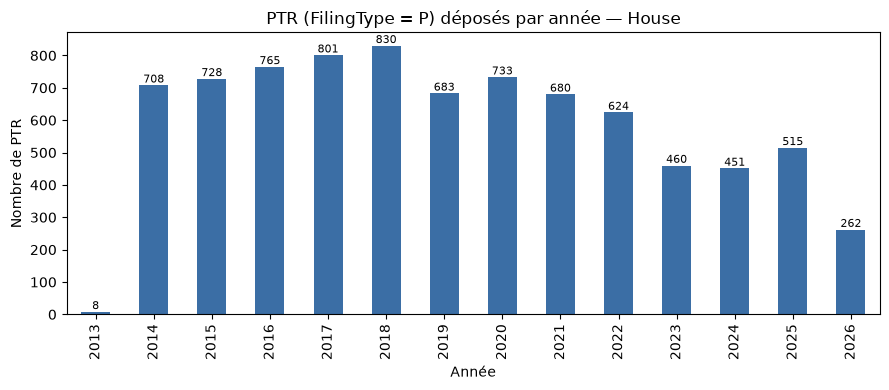

In [8]:
try:
    import matplotlib.pyplot as plt
    ax = coverage["n_ptr"].plot(kind="bar", figsize=(9, 4), color="#3b6ea5")
    ax.set_title("PTR (FilingType = P) déposés par année — House")
    ax.set_xlabel("Année"); ax.set_ylabel("Nombre de PTR")
    for i, v in enumerate(coverage["n_ptr"]):
        ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()
except Exception as exc:
    print("Graphe ignoré (matplotlib indisponible ?):", exc)

## 7. Index des PTR à télécharger — pont vers les Jours 3–4

Un `ptr_index_<ANNÉE>.csv` par année : c'est **exactement** la liste des `DocID` (et donc des
URL `…/ptr-pdfs/<ANNÉE>/<DocID>.pdf`) à récupérer ensuite, et la *liste attendue* qui servira
à prouver la complétude du téléchargement.

In [8]:
ptr = df[df["filing_type"] == PTR_CODE].copy()
cols = ["doc_id", "prefix", "first", "last", "suffix", "state_dist", "year", "filing_date"]
for year, g in ptr.groupby("year"):
    g[cols].to_csv(OUT_DIR / f"ptr_index_{year}.csv", index=False)
print(f"{len(ptr)} PTR au total -> un fichier ptr_index_<ANNÉE>.csv par année")
if len(ptr):
    last_year = int(ptr["year"].max())
    print(f"Aperçu — {last_year} :")
    display(ptr[ptr["year"] == last_year][cols].head(10))

8248 PTR au total -> un fichier ptr_index_<ANNÉE>.csv par année
Aperçu — 2026 :


,doc_id,prefix,first,last,suffix,state_dist,year,filing_date
36230,20034201,Hon.,Mark,Alford,,MO04,2026,3/31/2026
36233,20033751,Hon.,Richard W.,Allen,,GA12,2026,1/15/2026
36234,20033945,Hon.,Richard W.,Allen,,GA12,2026,2/17/2026
36235,20034133,Hon.,Richard W.,Allen,,GA12,2026,3/11/2026
36236,20034315,Hon.,Richard W.,Allen,,GA12,2026,5/4/2026
36237,20034473,Hon.,Richard W.,Allen,,GA12,2026,6/5/2026
36238,20034740,Hon.,Richard W.,Allen,,GA12,2026,6/16/2026
36260,20034024,Hon.,Jake,Auchincloss,,MA04,2026,2/19/2026
36261,20034622,Hon.,Jake,Auchincloss,,MA04,2026,5/22/2026
36264,20034522,Hon.,Brian,Babin,,TX36,2026,5/18/2026


## 8. Manifeste & contrôle de complétude

Provenance par année + repérage des années problématiques (échec de téléchargement ou 0 PTR).

In [9]:
display(manifest_df)
problemes = manifest_df[(~manifest_df["ok"]) | (manifest_df["n_ptr"] == 0)]
if len(problemes):
    print("\n A VÉRIFIER (échec téléchargement ou 0 PTR) :")
    display(problemes[["year", "ok", "n_ptr"]])
else:
    print("Toutes les années : téléchargement OK et >= 1 PTR.")
manifest_df.to_csv(OUT_DIR / "manifest.csv", index=False)

,year,url,ok,bytes,n_records,n_ptr,filing_types
0,2013,https://disclosures-clerk.house.gov/public_dis...,True,81472,2209,8,A;B;C;D;E;G;O;P;R;T;W;X
1,2014,https://disclosures-clerk.house.gov/public_dis...,True,97024,2788,708,A;C;D;E;G;H;O;P;T;W;X
2,2015,https://disclosures-clerk.house.gov/public_dis...,True,76338,2297,728,A;C;D;E;G;O;P;T;W;X
3,2016,https://disclosures-clerk.house.gov/public_dis...,True,92045,2704,765,A;C;D;G;H;O;P;T;W;X
4,2017,https://disclosures-clerk.house.gov/public_dis...,True,121192,3488,801,A;C;D;E;G;O;P;T;W;X
5,2018,https://disclosures-clerk.house.gov/public_dis...,True,119377,3443,830,A;B;C;D;E;G;H;O;P;T;W;X
6,2019,https://disclosures-clerk.house.gov/public_dis...,True,127181,3636,683,A;C;D;E;O;P;T;W;X
7,2020,https://disclosures-clerk.house.gov/public_dis...,True,98082,2930,733,A;C;D;E;H;O;P;T;W;X
8,2021,https://disclosures-clerk.house.gov/public_dis...,True,95555,2718,680,A;B;C;D;E;G;H;O;P;T;W;X
9,2022,https://disclosures-clerk.house.gov/public_dis...,True,95674,2743,624,A;B;C;D;G;H;O;P;T;W;X


Toutes les années : téléchargement OK et >= 1 PTR.
